# Day 46 (2/2) — Support Vector Regression (SVR)

### The idea in one sentence
> Fit a curve with a **tube** around it: points **inside** the tube cost nothing; only points **outside** the tube
> push the curve around.

It is SVM turned into regression: the "street" from notebook 01 becomes a tube of width **ε (epsilon)** around the
prediction, and the points on or outside the tube are the **support vectors**.

### In this notebook
1. Scale **both X and y** (and why)
2. Train SVR and predict a salary
3. See the ε-tube and the support vectors
4. The `C` parameter: why the CEO salary is underpredicted
5. What happens without scaling

> 📖 Theory: [`theory.md`](theory.md) §12 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset[['Level']].values        # 2-D: one feature column
y = dataset['Salary'].values
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


**Position Salaries:** 10 job levels and their salaries. It is a tiny demo dataset, so there is **no train/test
split**: we use it to *see* how each model draws its curve. The question: *a new hire says they were at level 6.5 and
earned 160,000. Is that believable?*

## 1. Scale X **and** y

SVR measures distances and its tube width ε is a fixed number (default 0.1). With salaries in the hundreds of
thousands, a tube of width 0.1 would be meaningless. Standardising both X and y puts everything on a scale of
roughly −1 to 3. Two separate scalers are needed, one for X and one for y, so that we can **convert predictions back
to real salaries** afterwards.

> ✍️ **Core code: learn this.** Two scalers; `y` must be 2-D for the scaler, then flattened back with `.ravel()`.

In [3]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()
X_sc = sc_X.fit_transform(X)
y_sc = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

print(np.c_[X_sc.round(2), y_sc.round(2)][:4])

[[-1.57 -0.72]
 [-1.22 -0.7 ]
 [-0.87 -0.67]
 [-0.52 -0.6 ]]


## 2. Train and predict

> ✍️ **Core code: learn this.** Predict in scaled units, then convert back with `inverse_transform`.

In [4]:
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X_sc, y_sc)

def predict_salary(model, level):
    scaled = model.predict(sc_X.transform([[level]]))
    return sc_y.inverse_transform(scaled.reshape(-1, 1))[0, 0]

print("Level 6.5 ->", round(predict_salary(regressor, 6.5)))
print("Level 10  ->", round(predict_salary(regressor, 10)), "(actual: 1,000,000)")

Level 6.5 -> 170370
Level 10  -> 557822 (actual: 1,000,000)


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

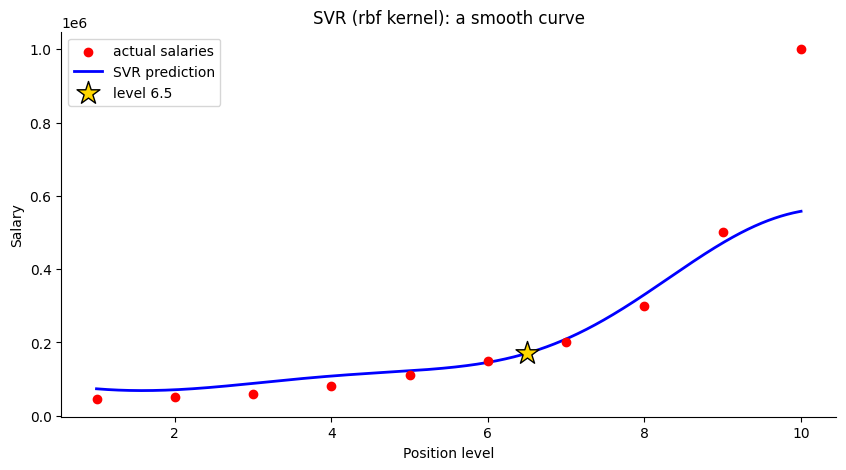

In [5]:
X_grid = np.arange(1, 10.01, 0.01).reshape(-1, 1)

def curve(model):
    return sc_y.inverse_transform(model.predict(sc_X.transform(X_grid)).reshape(-1, 1)).ravel()

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='red', zorder=3, label='actual salaries')
plt.plot(X_grid, curve(regressor), color='blue', linewidth=2, label='SVR prediction')
plt.scatter([6.5], [predict_salary(regressor, 6.5)], marker='*', s=300, color='gold', edgecolor='k', zorder=4,
            label='level 6.5')
plt.title('SVR (rbf kernel): a smooth curve')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.legend()
plt.show()

A smooth curve that fits levels 1–9 well and predicts about **170,000** for level 6.5. But the **CEO (level 10)** is
far off: about 558,000 predicted vs 1,000,000 actual. Why? See the tube.

## 3. The ε-tube and the support vectors

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

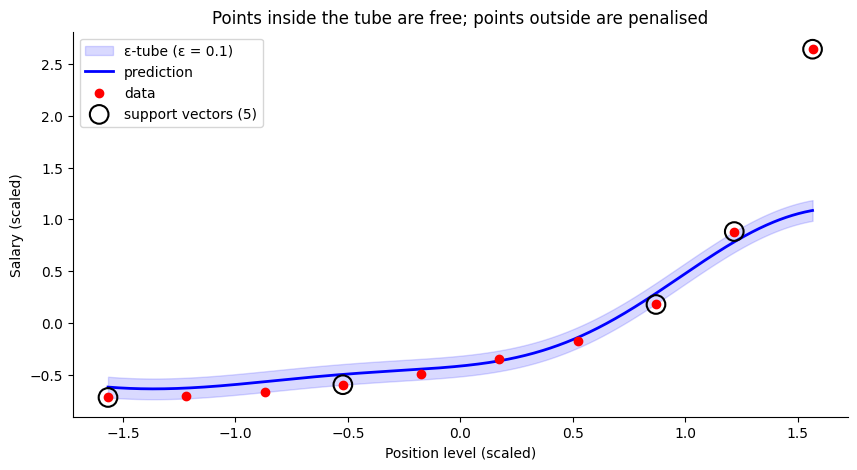

In [6]:
grid_sc = sc_X.transform(X_grid)
pred_sc = regressor.predict(grid_sc)
eps = regressor.epsilon
sv = regressor.support_

plt.figure(figsize=(10, 5))
plt.fill_between(grid_sc.ravel(), pred_sc - eps, pred_sc + eps, color='blue', alpha=0.15, label=f'ε-tube (ε = {eps})')
plt.plot(grid_sc, pred_sc, color='blue', linewidth=2, label='prediction')
plt.scatter(X_sc, y_sc, color='red', zorder=3, label='data')
plt.scatter(X_sc[sv], y_sc[sv], s=180, facecolors='none', edgecolors='black', linewidths=1.5, zorder=4,
            label=f'support vectors ({len(sv)})')
plt.xlabel('Position level (scaled)')
plt.ylabel('Salary (scaled)')
plt.title('Points inside the tube are free; points outside are penalised')
plt.legend()
plt.show()

- Points **inside** the tube cost nothing: SVR is happy with "close enough".
- Points **on the edge of or outside** the tube (circled) are the support vectors; each costs a penalty proportional to how far outside it is, multiplied by **C**.
- With the default `C = 1`, the penalty for the CEO is not large enough to bend the smooth curve all the way up.

## 4. The `C` parameter

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

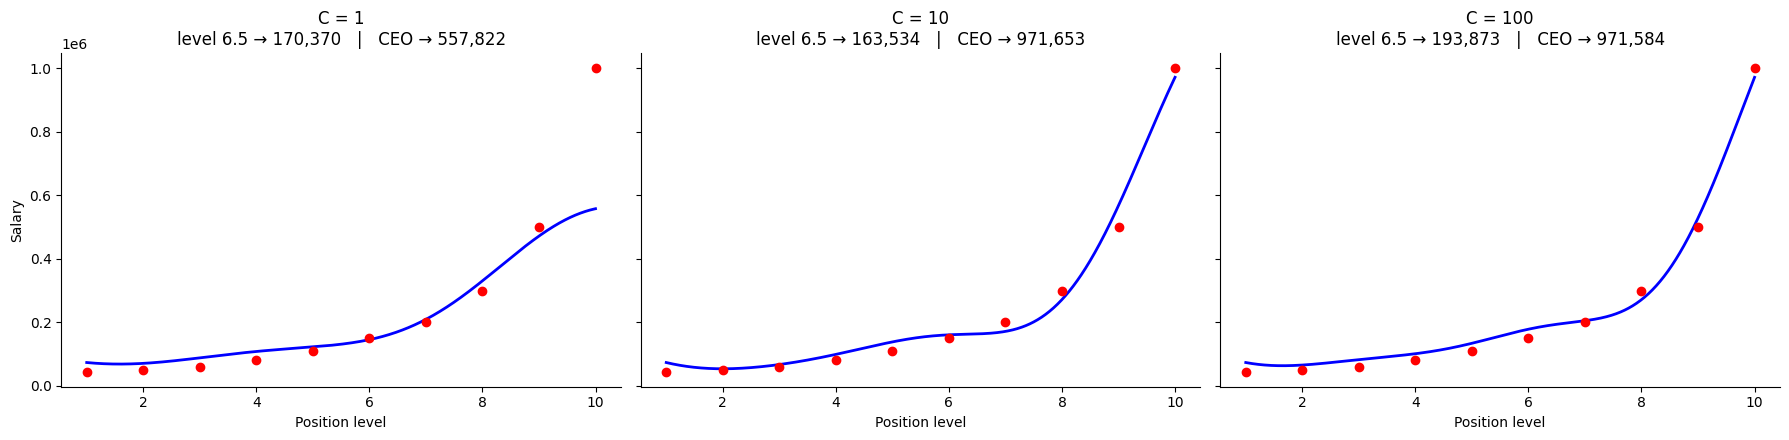

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, C in zip(axes, [1, 10, 100]):
    m = SVR(kernel='rbf', C=C).fit(X_sc, y_sc)
    ax.scatter(X, y, color='red', zorder=3)
    ax.plot(X_grid, curve(m), color='blue', linewidth=2)
    ax.set_title(f'C = {C}\nlevel 6.5 → {predict_salary(m, 6.5):,.0f}   |   CEO → {predict_salary(m, 10):,.0f}')
    ax.set_xlabel('Position level')
axes[0].set_ylabel('Salary')
plt.tight_layout()
plt.show()

Larger `C` = points outside the tube are punished more, so the curve bends to reach the CEO. Too large a `C` can
overfit noisy data, so choose it by cross-validation on real datasets.

| Parameter | Meaning |
|---|---|
| `C` | penalty for points outside the tube (larger = follows the data more closely) |
| `epsilon` | half-width of the tube (larger = more points are "free", smoother curve) |
| `kernel` | `'rbf'` for curves, `'linear'` for a straight line |

## 5. What if we don't scale?

In [8]:
unscaled = SVR(kernel='rbf').fit(X, y)
print("Without scaling, level 6.5 ->", round(unscaled.predict([[6.5]])[0]))
print("Without scaling, level 10  ->", round(unscaled.predict([[10]])[0]))

Without scaling, level 6.5 -> 130002
Without scaling, level 10  -> 130003


Without scaling the model is useless: it predicts almost the **same** value for every level, because a tube of width
0.1 on salaries in the hundreds of thousands, together with the default `C = 1`, means the penalties are tiny compared
with the numbers involved. **Always scale X and y for SVR.**

---
## Key takeaways
- SVR fits a function with an **ε-tube**; only points outside the tube (support vectors) influence it.
- `C` controls how hard outside points pull on the curve; `epsilon` controls the tube width.
- **Scale both X and y**, and convert predictions back with `inverse_transform`.
- `kernel='rbf'` gives smooth, non-linear curves.

## 🧠 Quick check

<details><summary>1. Which points influence an SVR model?</summary>

Only the support vectors: points on or outside the ε-tube.
</details>

<details><summary>2. Why is the CEO salary underpredicted with C = 1?</summary>

The penalty for being outside the tube is too small to pull the smooth curve up to that extreme value; a larger C fixes it.
</details>

<details><summary>3. Why do we need two scalers?</summary>

X and y have different scales; we need `sc_y` to convert scaled predictions back to real salaries.
</details>